<a href="https://colab.research.google.com/github/thikrar/Medical-Appointment-No-show-Analysis/blob/main/medical_appointment_no_show_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

In [58]:
!pip install kagglehub[pandas-datasets]

In [59]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "KaggleV2-May-2016.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "joniarroba/noshowappointments",
    file_path
)

df.head()

/tmp/ipykernel_2857/2494673972.py:6: DeprecationWarning:

Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.



Using Colab cache for faster access to the 'noshowappointments' dataset.


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [60]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [61]:
df.shape

(110527, 14)

In [62]:
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

In [63]:
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])

df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

Observation: The dataset contains no missing values Also ScheduledDay
AppointmentDay must be datetime

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110527 non-null  float64            
 1   AppointmentID   110527 non-null  int64              
 2   Gender          110527 non-null  object             
 3   ScheduledDay    110527 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110527 non-null  datetime64[ns, UTC]
 5   Age             110527 non-null  int64              
 6   Neighbourhood   110527 non-null  object             
 7   Scholarship     110527 non-null  int64              
 8   Hipertension    110527 non-null  int64              
 9   Diabetes        110527 non-null  int64              
 10  Alcoholism      110527 non-null  int64              
 11  Handcap         110527 non-null  int64              
 12  SMS_received    110527 non-null  int64              
 13  No-show       

In [65]:
df["Age"].describe()

,Age
count,110527.000000
mean,37.088874
std,23.110205
min,-1.000000
25%,18.000000
50%,37.000000
75%,55.000000
max,115.000000


Minimum Age = -1 Invalid Data

In [66]:
df[df["Age"] < 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659432e+14,5775010,F,2016-06-06 08:58:13+00:00,2016-06-06 00:00:00+00:00,-1,ROMÃO,0,0,0,0,0,0,No


Inspect before modifying So, we removed one record with an invalid age (-1), as it represented an impossible value

In [67]:
df = df[df["Age"] >= 0]

In [68]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105260e+05,1.105260e+05,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000
mean,1.474934e+14,5.675304e+06,37.089219,0.098266,0.197248,0.071865,0.030400,0.022248,0.321029
std,2.560943e+14,7.129544e+04,23.110026,0.297676,0.397923,0.258266,0.171686,0.161543,0.466874
min,3.921784e+04,5.030230e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172536e+12,5.640285e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680572e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.438963e+13,5.725523e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [69]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset

In [70]:
df["No-show"].value_counts()

,count
No-show,
No,88207
Yes,22319


In [71]:
df["Gender"].value_counts()

,count
Gender,
F,71839
M,38687


In [72]:
df["Diabetes"].value_counts()

,count
Diabetes,
0,102583
1,7943


Exploratory Data Analysis

In [73]:
df["No-show"].value_counts()

,count
No-show,
No,88207
Yes,22319


In [74]:
(df["No-show"].value_counts(normalize=True) * 100).round(2)

,proportion
No-show,
No,79.81
Yes,20.19


Approximately 20% of appointments resulted in no-shows

In [75]:
pd.crosstab(
    df["Gender"],
    df["No-show"],
    normalize="index"
) * 100

No-show,No,Yes
Gender,,
F,79.685129,20.314871
M,80.032052,19.967948


**Observation:** Approximately 20% of all appointments resulted in patient no-shows.

**Insight:** This indicates that missed appointments are a significant issue and may reduce healthcare service efficiency.

**Recommendation:** Investigate the factors associated with no-shows and implement targeted interventions, such as appointment reminders, to improve attendance.



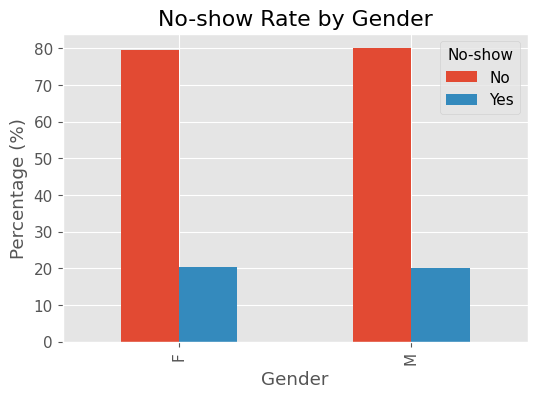

In [76]:
import matplotlib.pyplot as plt

gender_attendance = pd.crosstab(
    df["Gender"],
    df["No-show"],
    normalize="index"
) * 100

gender_attendance.plot(kind="bar", figsize=(6,4))

plt.title("No-show Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(title="No-show")
plt.show()

**Observation:** The no-show rates for males and females were very similar, with only a slight difference between the two groups.

**Insight:** Gender does not appear to have a significant impact on appointment attendance.

**Recommendation:** Focus on other factors, such as age, waiting time, and SMS reminders, which may have a stronger influence on no-show rates.


<Figure size 800x500 with 0 Axes>

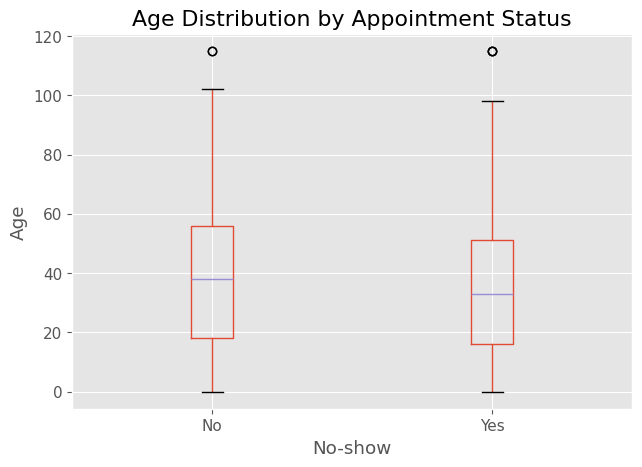

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.boxplot(column="Age", by="No-show")

plt.title("Age Distribution by Appointment Status")
plt.suptitle("")
plt.xlabel("No-show")
plt.ylabel("Age")
plt.show()

Patients who attended appointments appear to have a slightly lower median age than those who missed them, although the difference is small

In [78]:
pd.crosstab(
    df["SMS_received"],
    df["No-show"],
    normalize="index"
).round(3) * 100

No-show,No,Yes
SMS_received,,
0,83.3,16.7
1,72.4,27.6


Patients who received SMS reminders had a higher no-show rate (27.6%) than those who did not receive SMS reminders (16.7%).
The higher no-show rate among patients who received SMS reminders suggests that SMS reminders alone may not explain appointment attendance. Other factors are likely influencing this relationship.

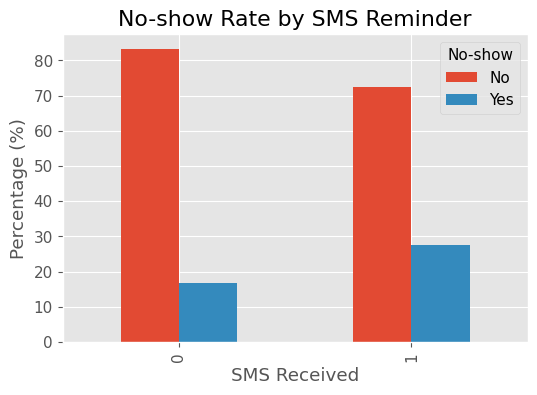

In [79]:
sms_attendance = pd.crosstab(
    df["SMS_received"],
    df["No-show"],
    normalize="index"
) * 100

sms_attendance.plot(kind="bar", figsize=(6,4))

plt.title("No-show Rate by SMS Reminder")
plt.xlabel("SMS Received")
plt.ylabel("Percentage (%)")
plt.legend(title="No-show")
plt.show()

In [80]:
df["WaitingDays"] = (
    df["AppointmentDay"] - df["ScheduledDay"]
).dt.days

In [81]:
df["WaitingDays"].describe()

,WaitingDays
count,110526.000000
mean,9.183794
std,15.255034
min,-7.000000
25%,-1.000000
50%,3.000000
75%,14.000000
max,178.000000


In [82]:
df[["ScheduledDay", "AppointmentDay"]].head(10)

,ScheduledDay,AppointmentDay
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00
5,2016-04-27 08:36:51+00:00,2016-04-29 00:00:00+00:00
6,2016-04-27 15:05:12+00:00,2016-04-29 00:00:00+00:00
7,2016-04-27 15:39:58+00:00,2016-04-29 00:00:00+00:00
8,2016-04-29 08:02:16+00:00,2016-04-29 00:00:00+00:00
9,2016-04-27 12:48:25+00:00,2016-04-29 00:00:00+00:00


In [83]:
df["WaitingDays"] = (
    df["AppointmentDay"].dt.normalize() -
    df["ScheduledDay"].dt.normalize()
).dt.days

In [84]:
df["WaitingDays"].describe()

,WaitingDays
count,110526.000000
mean,10.183794
std,15.255034
min,-6.000000
25%,0.000000
50%,4.000000
75%,15.000000
max,179.000000


In [85]:
(df["WaitingDays"] < 0).sum()

np.int64(5)

In [86]:
df = df[df["WaitingDays"] >= 0]

In [87]:
(df["WaitingDays"] < 0).sum()

np.int64(0)

<Figure size 800x500 with 0 Axes>

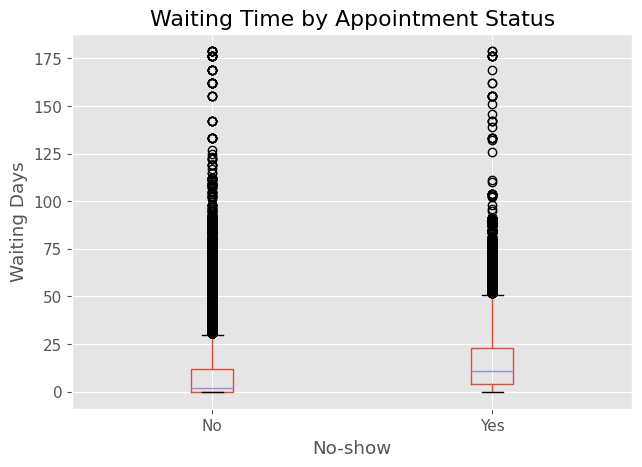

In [88]:
plt.figure(figsize=(8,5))

df.boxplot(column="WaitingDays", by="No-show")

plt.title("Waiting Time by Appointment Status")
plt.suptitle("")
plt.xlabel("No-show")
plt.ylabel("Waiting Days")
plt.show()

In [89]:
df.groupby("No-show")["WaitingDays"].describe()

,count,mean,std,min,25%,50%,75%,max
No-show,,,,,,,,
No,88207.0,8.754759,14.55045,0.0,0.0,2.0,12.0,179.0
Yes,22314.0,15.835484,16.60560,0.0,4.0,11.0,23.0,179.0


In [90]:
bins = [-1, 0, 7, 30, 179]

labels = [
    "Same Day",
    "1-7 Days",
    "8-30 Days",
    "30+ Days"
]

df["WaitingGroup"] = pd.cut(
    df["WaitingDays"],
    bins=bins,
    labels=labels
)

In [91]:
df[["WaitingDays", "WaitingGroup"]].head(10)

,WaitingDays,WaitingGroup
0,0,Same Day
1,0,Same Day
2,0,Same Day
3,0,Same Day
4,0,Same Day
5,2,1-7 Days
6,2,1-7 Days
7,2,1-7 Days
8,0,Same Day
9,2,1-7 Days


In [92]:
pd.crosstab(
    df["WaitingGroup"],
    df["No-show"],
    normalize="index"
).round(3) * 100

No-show,No,Yes
WaitingGroup,,
Same Day,95.4,4.6
1-7 Days,75.9,24.1
8-30 Days,68.3,31.7
30+ Days,67.0,33.0


There is a strong association between longer waiting times and higher no-show rates. Patients are considerably more likely to miss their appointments when they wait longer

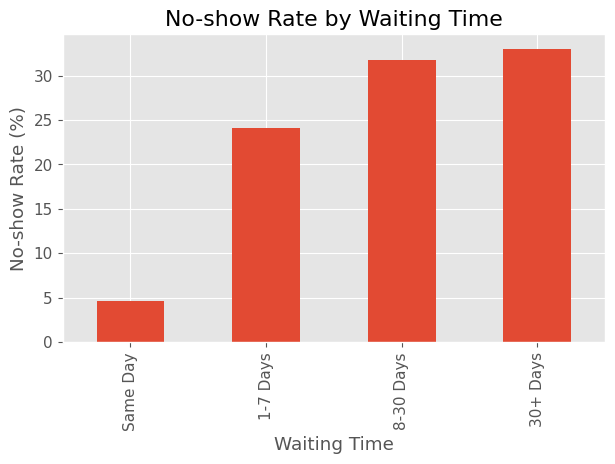

In [93]:
waiting_rate = pd.crosstab(
    df["WaitingGroup"],
    df["No-show"],
    normalize="index"
) * 100

waiting_rate["Yes"].plot(kind="bar", figsize=(7,4))

plt.title("No-show Rate by Waiting Time")
plt.xlabel("Waiting Time")
plt.ylabel("No-show Rate (%)")
plt.show()

In [94]:
pd.crosstab(
    df["Diabetes"],
    df["No-show"],
    normalize="index"
).round(3) * 100

No-show,No,Yes
Diabetes,,
0,79.6,20.4
1,82.0,18.0


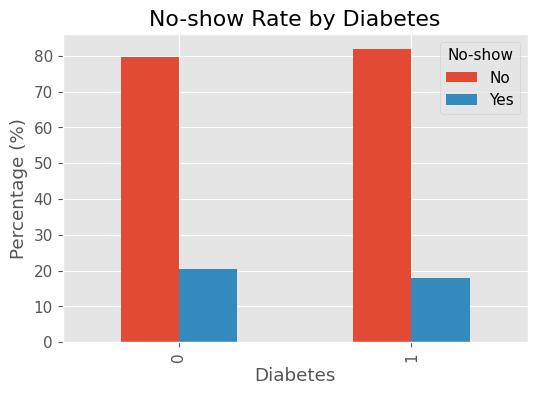

In [95]:
diabetes_rate = pd.crosstab(
    df["Diabetes"],
    df["No-show"],
    normalize="index"
) * 100

diabetes_rate.plot(kind="bar", figsize=(6,4))

plt.title("No-show Rate by Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Percentage (%)")
plt.legend(title="No-show")
plt.show()

In [96]:
df["Neighbourhood"].nunique()

81

In [97]:
neighbourhood_rate = pd.crosstab(
    df["Neighbourhood"],
    df["No-show"],
    normalize="index"
) * 100

neighbourhood_rate = neighbourhood_rate.sort_values(
    by="Yes",
    ascending=False
)

neighbourhood_rate.head(10)

No-show,No,Yes
Neighbourhood,,
ILHAS OCEÂNICAS DE TRINDADE,0.000000,100.000000
SANTOS DUMONT,71.081505,28.918495
SANTA CECÍLIA,72.544643,27.455357
SANTA CLARA,73.517787,26.482213
ITARARÉ,73.733637,26.266363
JESUS DE NAZARETH,75.604627,24.395373
HORTO,76.000000,24.000000
ILHA DO PRÍNCIPE,76.522507,23.477493
CARATOÍRA,76.959064,23.040936


In [98]:
pd.crosstab(
    df["Scholarship"],
    df["No-show"],
    normalize="index"
).round(3) * 100

No-show,No,Yes
Scholarship,,
0,80.2,19.8
1,76.3,23.7


In [99]:
# KPI Calculations

total_appointments = len(df)

attended = (df["No-show"] == "No").sum()

missed = (df["No-show"] == "Yes").sum()

no_show_rate = (missed / total_appointments) * 100

average_waiting = df["WaitingDays"].mean()

print(f"Total Appointments: {total_appointments}")
print(f"Attended: {attended}")
print(f"Missed: {missed}")
print(f"No-show Rate: {no_show_rate:.2f}%")
print(f"Average Waiting Days: {average_waiting:.2f}")

Total Appointments: 110521
Attended: 88207
Missed: 22314
No-show Rate: 20.19%
Average Waiting Days: 10.18


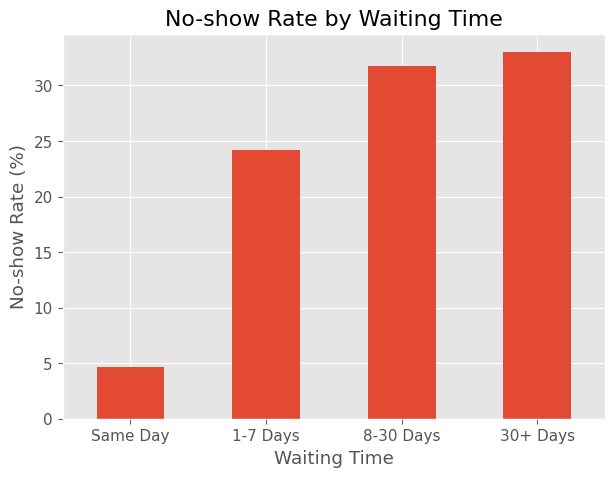

In [100]:
waiting_rate = pd.crosstab(
    df["WaitingGroup"],
    df["No-show"],
    normalize="index"
) * 100

waiting_rate["Yes"].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("No-show Rate by Waiting Time")
plt.xlabel("Waiting Time")
plt.ylabel("No-show Rate (%)")
plt.xticks(rotation=0)
plt.show()

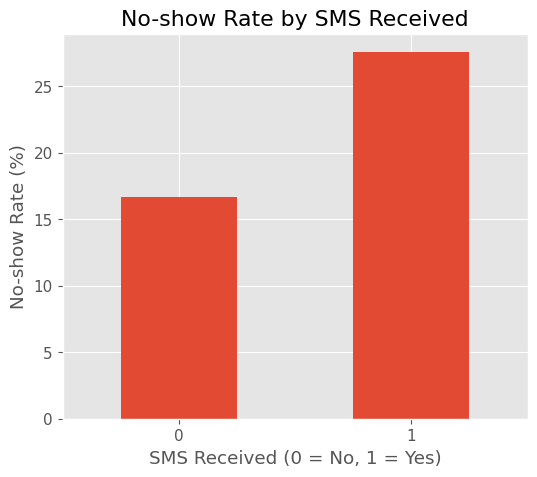

In [101]:
sms_rate = pd.crosstab(
    df["SMS_received"],
    df["No-show"],
    normalize="index"
) * 100

sms_rate["Yes"].plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("No-show Rate by SMS Received")
plt.xlabel("SMS Received (0 = No, 1 = Yes)")
plt.ylabel("No-show Rate (%)")
plt.xticks(rotation=0)
plt.show()

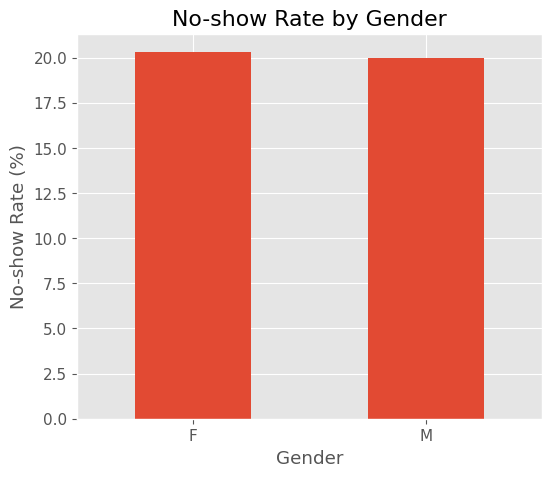

In [102]:
gender_rate = pd.crosstab(
    df["Gender"],
    df["No-show"],
    normalize="index"
) * 100

gender_rate["Yes"].plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("No-show Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("No-show Rate (%)")
plt.xticks(rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

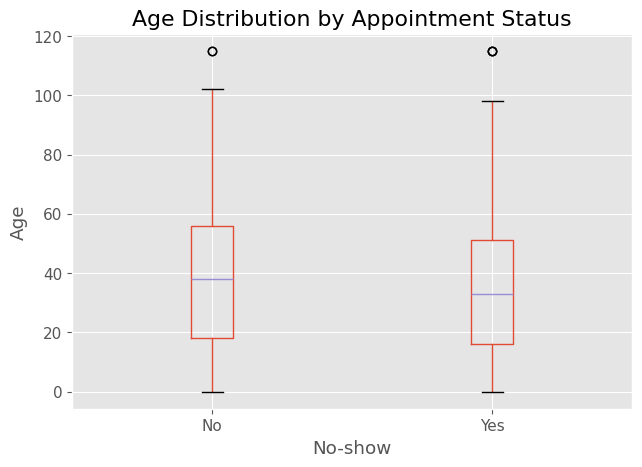

In [103]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="Age",
    by="No-show"
)

plt.title("Age Distribution by Appointment Status")
plt.suptitle("")
plt.xlabel("No-show")
plt.ylabel("Age")
plt.show()

In [104]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (7,5)
plt.rcParams["font.size"] = 11

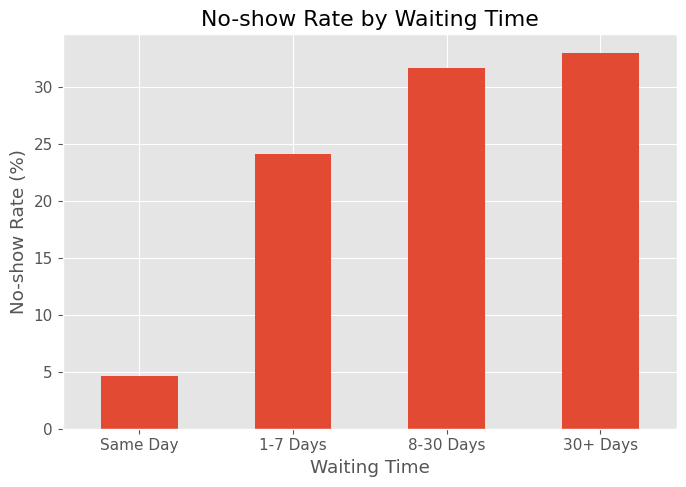

In [105]:
waiting_rate["Yes"].plot(kind="bar")

plt.title("No-show Rate by Waiting Time")
plt.xlabel("Waiting Time")
plt.ylabel("No-show Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

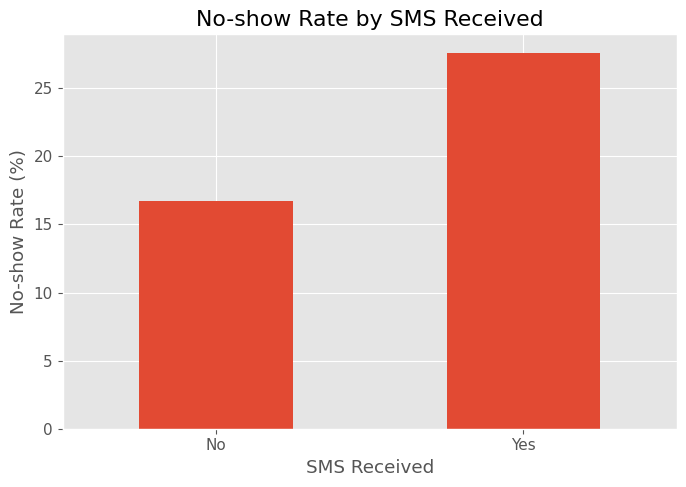

In [106]:
sms_rate["Yes"].plot(kind="bar")

plt.title("No-show Rate by SMS Received")
plt.xlabel("SMS Received")
plt.ylabel("No-show Rate (%)")
plt.xticks([0,1],["No","Yes"],rotation=0)

plt.tight_layout()

plt.show()

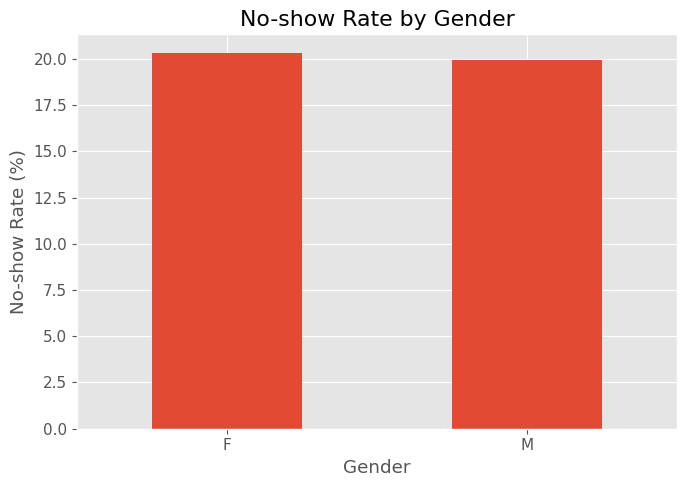

In [107]:
gender_rate["Yes"].plot(kind="bar")

plt.title("No-show Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("No-show Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

<Figure size 700x500 with 0 Axes>

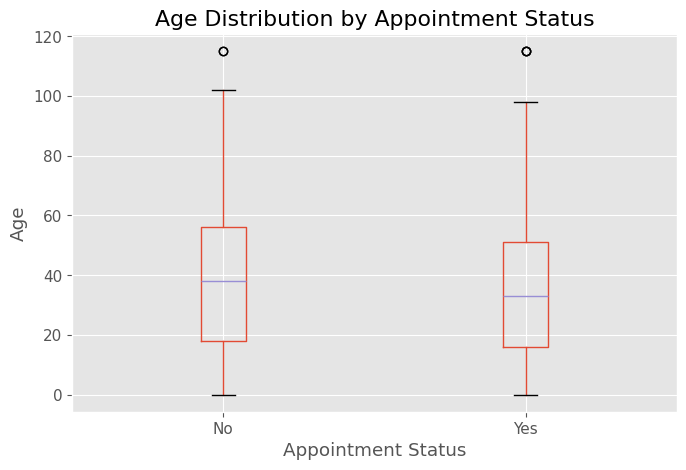

In [108]:
plt.figure(figsize=(7,5))

df.boxplot(column="Age", by="No-show")

plt.title("Age Distribution by Appointment Status")
plt.suptitle("")
plt.xlabel("Appointment Status")
plt.ylabel("Age")

plt.tight_layout()

plt.show()

In [109]:
!pip install plotly

In [110]:
import plotly.express as px
import plotly.graph_objects as go

In [111]:
fig = px.bar(
    waiting_rate.reset_index(),
    x="WaitingGroup",
    y="Yes",
    title="No-show Rate by Waiting Time",
    labels={
        "WaitingGroup": "Waiting Time",
        "Yes": "No-show Rate (%)"
    },
    text="Yes"
)

fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")

fig.show()

In [112]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Indicator(
    mode="number",
    value=total_appointments,
    title={"text": "Total Appointments"},
    domain={'x':[0,0.25],'y':[0.5,1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=attended,
    title={"text":"Attended"},
    domain={'x':[0.25,0.5],'y':[0.5,1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=missed,
    title={"text":"Missed"},
    domain={'x':[0.5,0.75],'y':[0.5,1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=no_show_rate,
    number={'suffix':"%",'valueformat':".1f"},
    title={"text":"No-show Rate"},
    domain={'x':[0.75,1],'y':[0.5,1]}
))

fig.update_layout(
    title="Medical Appointment Dashboard",
    height=300
)

fig.show()